In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik import resources
import warnings
warnings.filterwarnings('ignore')

In [106]:
salaries = pd.read_csv('salary_dataset.csv', encoding='utf-8') 
salaries.head()

,Unnamed: 0,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,UK,White
1,1,28.0,Female,Master's,Data Analyst,3.0,65000.0,USA,Hispanic
2,2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Canada,White
3,3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,USA,Hispanic
4,4,52.0,Male,Master's,Director,20.0,200000.0,USA,Asian


In [107]:
salaries.info()
#Сразу обратил внимание на то, что пропусков почти нет, соответственно принимаю решение их удалить.
#Колонка Unnamed: 0 похожа на индексацию внутри, по этому нужно проверить уникальность, и если что использовать индексы с этой колонки.
#По Dtype тоже принимаю решение в дальнейшем оптимизировать это всё. 

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           6704 non-null   int64  
 1   Age                  6702 non-null   float64
 2   Gender               6702 non-null   str    
 3   Education Level      6701 non-null   str    
 4   Job Title            6702 non-null   str    
 5   Years of Experience  6701 non-null   float64
 6   Salary               6699 non-null   float64
 7   Country              6704 non-null   str    
 8   Race                 6704 non-null   str    
dtypes: float64(3), int64(1), str(5)
memory usage: 471.5 KB


In [108]:
salaries.iloc[:, 0].nunique()
#Явно колонка с 0 индексом является индексами для таблицы

6704

In [3]:
salaries = pd.read_csv('salary_dataset.csv', encoding='utf-8', index_col=0) 
salaries.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,UK,White
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,USA,Hispanic
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Canada,White
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,USA,Hispanic
4,52.0,Male,Master's,Director,20.0,200000.0,USA,Asian


In [ ]:
salaries.describe().round(2).T
#В целом по данной статистике видно, что числовые данные не имеют явных выбросов, все значения абсолютно реальны.

,count,mean,std,min,25%,50%,75%,max
Age,6702.0,33.62,7.61,21.0,28.0,32.0,38.0,62.0
Years of Experience,6701.0,8.09,6.06,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,115326.96,52786.18,350.0,70000.0,115000.0,160000.0,250000.0


In [57]:
salaries.describe(include=['object', 'category']).T
#Появляются вопросы о Gender unique = 3.

,count,unique,top,freq
Gender,6702,3,Male,3674
Education Level,6701,7,Bachelor's Degree,2267
Job Title,6702,193,Software Engineer,518
Country,6704,5,USA,1360
Race,6704,10,White,1968


In [110]:
salaries['Gender'].unique()
#Вопрос по Gender отпал

<StringArray>
['Male', 'Female', nan, 'Other']
Length: 4, dtype: str

In [4]:
#Избавимся от пропусков, как было решено выше.
salaries = salaries.dropna()
salaries.info()


<class 'pandas.DataFrame'>
Index: 6698 entries, 0 to 6703
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6698 non-null   float64
 1   Gender               6698 non-null   str    
 2   Education Level      6698 non-null   str    
 3   Job Title            6698 non-null   str    
 4   Years of Experience  6698 non-null   float64
 5   Salary               6698 non-null   float64
 6   Country              6698 non-null   str    
 7   Race                 6698 non-null   str    
dtypes: float64(3), str(5)
memory usage: 471.0 KB


In [5]:
salaries.duplicated().sum()
#Делаю предположение о том, что дубликаты это работники, которые, скорее всего, выпустились вместе и пошли работать на одинаковые позиции, имеющие одно и то же образование, пол, опыт


np.int64(1535)

In [ ]:
duplicates = salaries[salaries.duplicated(keep=False)].sort_values(by=['Age', 'Country'])
print(duplicates)
#Довольно похоже на моё предположение, по этому решаю оставить дубликаты

       Age  Gender Education Level                    Job Title  \
4962  21.0  Female     High School  Junior Sales Representative   
5018  21.0  Female     High School  Junior Sales Representative   
5044  21.0  Female     High School  Junior Sales Representative   
5057  21.0  Female     High School  Junior Sales Representative   
5109  21.0  Female     High School  Junior Sales Representative   
...    ...     ...             ...                          ...   
1642  54.0    Male             PhD    Software Engineer Manager   
1674  55.0    Male             PhD    Software Engineer Manager   
1712  55.0    Male             PhD    Software Engineer Manager   
1246  56.0    Male             PhD    Software Engineer Manager   
1402  56.0    Male             PhD    Software Engineer Manager   

      Years of Experience    Salary    Country              Race  
4962                  0.0   25000.0  Australia             White  
5018                  0.0   25000.0  Australia             Wh

In [15]:
#При построении графиков увидел, что в Education level присутствуют 2 phd разными шрифтами, Bachelor's и Master's
salaries.loc[salaries['Education Level'].str.lower() == 'phd', 'Education Level'] = 'PhD'
salaries.loc[salaries['Education Level'] == "Bachelor's", 'Education Level'] = "Bachelor's Degree"
salaries.loc[salaries['Education Level'] == "Master's", 'Education Level'] = "Master's Degree"
salaries['Education Level'].unique()

<StringArray>
['Bachelor's Degree', 'Master's Degree', 'PhD', 'High School']
Length: 4, dtype: str

In [16]:
#Разберёмся с заменой dtype, как было решено выше
object_cols = salaries.select_dtypes(include=[object]).columns
float_cols = salaries.select_dtypes(include=['float64'])

for column in object_cols:
    salaries[column] = salaries[column].astype('category')
    
for column in float_cols:
    salaries[column] = pd.to_numeric(salaries[column], downcast='float')
salaries.info()

<class 'pandas.DataFrame'>
Index: 6698 entries, 0 to 6703
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  6698 non-null   float32 
 1   Gender               6698 non-null   category
 2   Education Level      6698 non-null   category
 3   Job Title            6698 non-null   category
 4   Years of Experience  6698 non-null   float32 
 5   Salary               6698 non-null   float32 
 6   Country              6698 non-null   category
 7   Race                 6698 non-null   category
dtypes: category(5), float32(3)
memory usage: 171.7 KB


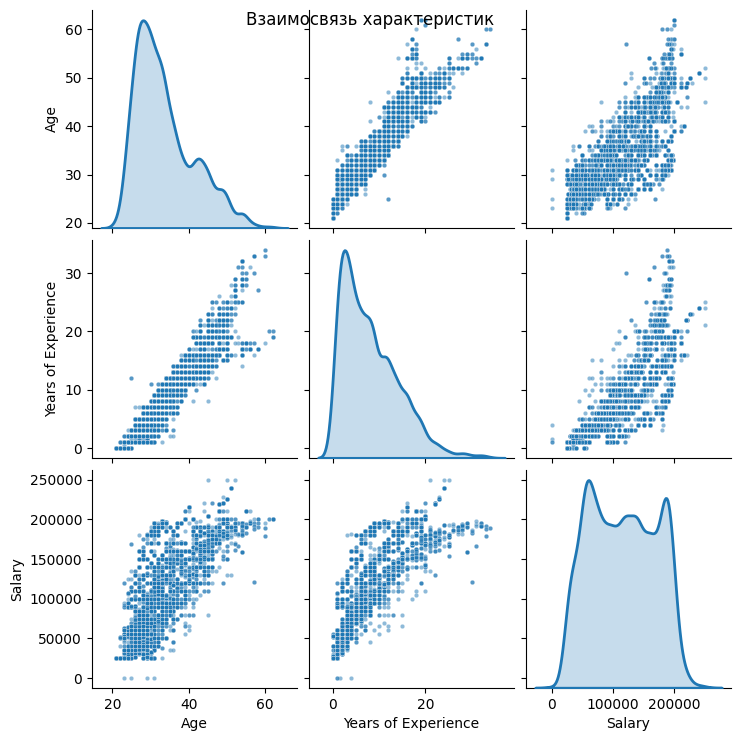

In [17]:
#Вообще интересно посмотреть визуальный анализ взаимосвязей
sns.pairplot(salaries, diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 10},
             diag_kws={'linewidth': 2})
plt.suptitle('Взаимосвязь характеристик')
plt.show()
#Ну что и следовало ожидать: Чем старше, тем выше зарплата, при этом в один момент она перестает увеличиваться; С опытом абсолютно такая же ситуация


interval columns not set, guessing: ['Age', 'Years of Experience', 'Salary']


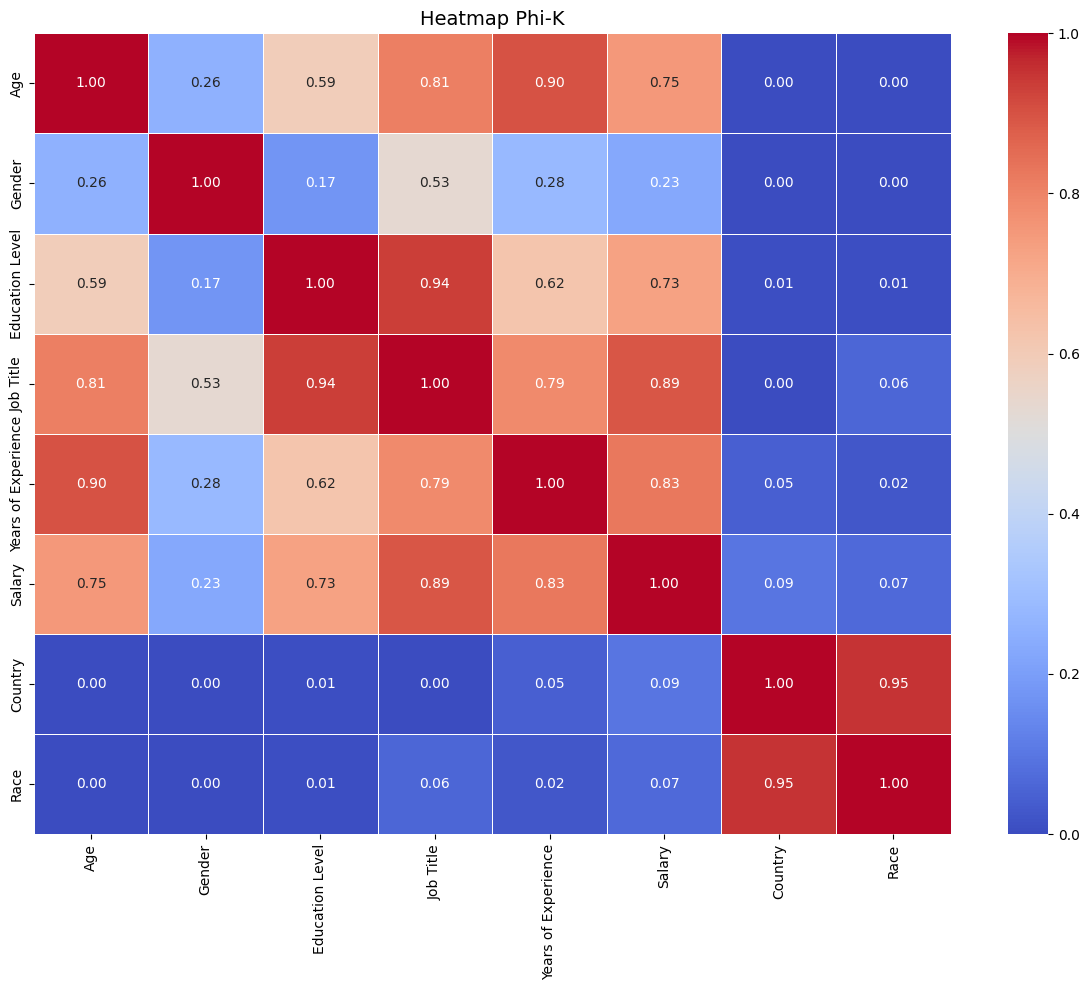

In [18]:
#Подкрепим это всё корреляционным анализом с помощью phi-k
phi_k_corr_matrix = salaries.phik_matrix()

plt.figure(figsize=(12, 10))
sns.heatmap(phi_k_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Phi-K', fontsize=14)
plt.tight_layout() # Для автоматической подгонки элементов
plt.show()
#В целом прошлое предложение подтверждается корреляционным анализом, ещё, что интересно, у Education Level и Salary так же явно есть корреляция


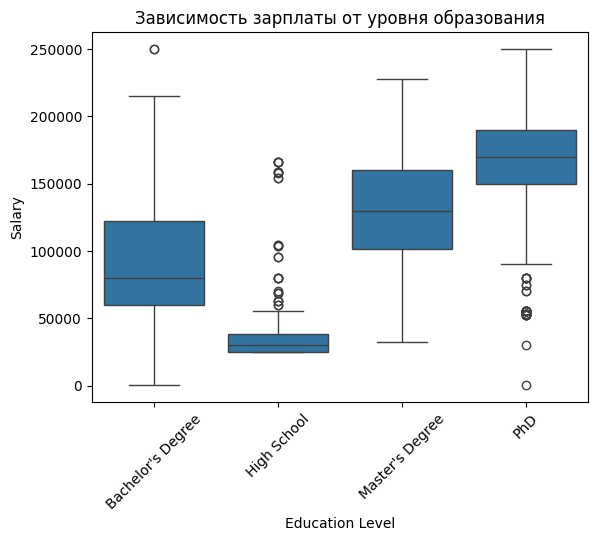

In [ ]:
sns.boxplot(data=salaries, x='Education Level', y='Salary')
plt.title('Зависимость зарплаты от уровня образования')
plt.xticks(rotation=45)
plt.show()
#Интересно, что при boxplot присутствуют выбросы в High School и PhD(один выброс в Bachelor's Degree), появилась идея посмотреть вообще количество людей по каждому уровню образованию

In [ ]:
salaries.groupby('Education Level').size()
#Абсолютно разное количество данных, при этом при малом количестве данных с Education Level == Bachelor's Degree выбросов там наиболее большее количество, но они могут соответствовать реальности, тут не хватает данных, чтобы сделать какой-то определенный вывод, но, возможно, это талантливые люди.
#Касаемо PhD я могу сделать предположение, что часто это люди, которые посвятили свою жизнь науке и открытиям, как, например, Григорий Перельман

Education Level
Bachelor's Degree    3021
High School           448
Master's Degree      1860
PhD                  1369
dtype: int64